In [ ]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)

ds = fetch_ucirepo(id=296)
df = ds.data.features.copy()
df["readmitted"] = ds.data.targets["readmitted"]

# Binary target: 1 = readmitted within 30 days (the costly event), 0 = not
df["target"] = (df["readmitted"] == "<30").astype(int)

n = len(df)
pos = df["target"].sum()
print(f"Encounters: {n:,}")
print(f"Positive (readmit <30d): {pos:,}  ({pos/n:.1%})")
print(f"Negative:                {n-pos:,}  ({1-pos/n:.1%})")
print(f"\nImbalance ratio: 1 positive for every {(n-pos)/pos:.1f} negatives")

In [ ]:
# The '?' trap: missing values are stored as the literal string "?",
# so pandas doesn't flag them as NaN. df.info() would look deceptively clean.
print("Columns with disguised missing values ('?'):\n")
q_counts = (df == "?").sum()
q_counts = q_counts[q_counts > 0].sort_values(ascending=False)
for col, cnt in q_counts.items():
    print(f"  {col:25s} {cnt:7,}  ({cnt/n:.1%})")

print(f"\nColumns affected: {len(q_counts)}")

In [ ]:
# Check for real NaN missing values (ucimlrepo may have already converted '?' -> NaN)
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("Columns with missing values (NaN):\n")
for col, cnt in miss.items():
    print(f"  {col:25s} {cnt:7,}  ({cnt/n:.1%})")
print(f"\nColumns affected: {len(miss)}")

In [ ]:
# ID columns (identifiers, not features) and a look at the target-adjacent columns
print("Shape:", df.shape)
print("\nID-like columns present:",
      [c for c in ["encounter_id", "patient_nbr"] if c in df.columns])

# The repeat-patient trap: same patient can appear many times
if "patient_nbr" in df.columns:
    dup = df["patient_nbr"].duplicated().sum()
    print(f"Duplicate patient encounters: {dup:,} "
          f"({dup/n:.1%} of rows are repeat visits)")
    print(f"Unique patients: {df['patient_nbr'].nunique():,}")

In [ ]:
# ucimlrepo often separates IDs into ds.data.ids
print("Available data attributes:")
for attr in ["features", "targets", "ids"]:
    obj = getattr(ds.data, attr, None)
    if obj is not None:
        print(f"  ds.data.{attr}: shape {obj.shape}, columns {list(obj.columns)[:5]}")
    else:
        print(f"  ds.data.{attr}: None")

In [ ]:
ids = ds.data.ids
df["patient_nbr"] = ids["patient_nbr"].values

dup = df["patient_nbr"].duplicated().sum()
print(f"Total encounters:  {len(df):,}")
print(f"Unique patients:   {df['patient_nbr'].nunique():,}")
print(f"Repeat encounters: {dup:,}  ({dup/len(df):.1%} of rows are not a patient's first visit)")

# How many patients have multiple visits?
visits = df["patient_nbr"].value_counts()
multi = (visits > 1).sum()
print(f"\nPatients with >1 visit: {multi:,}")
print(f"Max visits by one patient: {visits.max()}")

In [ ]:
import sys
sys.path.insert(0, "../src")
from readmit.clean import load_clean

clean_df = load_clean()
print("Cleaned shape:", clean_df.shape)
print("Target rate:", f"{clean_df['target'].mean():.1%}")
print("Any missing left:", clean_df.isna().sum().sum())
print("\nColumns:", list(clean_df.columns))

In [ ]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from readmit.clean import load_clean

sns.set_theme(style="whitegrid")
df = load_clean()
BASE_RATE = df["target"].mean()
print(f"Rows: {len(df):,}   Base readmission rate: {BASE_RATE:.1%}")

In [ ]:
# Hypothesis 1: more prior inpatient visits -> higher readmission rate
feat = "number_inpatient"
tab = (df.groupby(feat)["target"]
         .agg(["mean", "count"])
         .rename(columns={"mean": "readmit_rate", "count": "n"}))
tab = tab[tab["n"] >= 30]  # ignore tiny bins (unreliable rates)
print(tab.head(12))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(tab.index, tab["readmit_rate"], color="steelblue")
ax.axhline(BASE_RATE, color="crimson", linestyle="--", label=f"base rate {BASE_RATE:.1%}")
ax.set_xlabel("prior inpatient visits (past year)")
ax.set_ylabel("readmission rate")
ax.set_title("Readmission rate rises sharply with prior inpatient visits")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Hypothesis 2: more diagnoses -> higher readmission rate
feat = "number_diagnoses"
tab = (df.groupby(feat)["target"]
         .agg(["mean", "count"])
         .rename(columns={"mean": "readmit_rate", "count": "n"}))
tab = tab[tab["n"] >= 30]
print(tab)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(tab.index, tab["readmit_rate"], color="seagreen")
ax.axhline(BASE_RATE, color="crimson", linestyle="--", label=f"base rate {BASE_RATE:.1%}")
ax.set_xlabel("number of diagnoses")
ax.set_ylabel("readmission rate")
ax.set_title("Readmission rate vs. number of diagnoses")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Hypothesis 3: discharge disposition (categorical) vs readmission
feat = "discharge_disposition_id"
tab = (df.groupby(feat)["target"]
         .agg(["mean", "count"])
         .rename(columns={"mean": "readmit_rate", "count": "n"}))
tab = tab[tab["n"] >= 100].sort_values("readmit_rate", ascending=False)
print(tab.head(12))

fig, ax = plt.subplots(figsize=(8, 4))
top = tab.head(10)
ax.barh(top.index.astype(str), top["readmit_rate"], color="darkorange")
ax.axvline(BASE_RATE, color="crimson", linestyle="--", label=f"base rate {BASE_RATE:.1%}")
ax.set_xlabel("readmission rate")
ax.set_ylabel("discharge_disposition_id")
ax.set_title("Readmission rate by discharge disposition (top 10)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Deceased/hospice dispositions can't be readmitted - must be removed
expired_hospice = [11, 13, 14, 19, 20, 21]  # expired or hospice per mapping
present = df["discharge_disposition_id"].isin(expired_hospice).sum()
print(f"Rows with expired/hospice disposition: {present:,} ({present/len(df):.1%})")
print(df[df["discharge_disposition_id"].isin(expired_hospice)]
      .groupby("discharge_disposition_id")["target"].agg(["mean","count"]))

In [ ]:
from importlib import reload
import readmit.clean as clean_mod
reload(clean_mod)

df2 = clean_mod.load_clean()
print("Rows before fix: 71,518")
print(f"Rows after removing expired/hospice: {len(df2):,}")
print(f"New base rate: {df2['target'].mean():.1%}")
# Confirm none remain
remaining = df2["discharge_disposition_id"].isin([11,13,14,19,20,21]).sum()
print(f"Expired/hospice rows remaining: {remaining}")

In [15]:
# What types of features do we have?
X = df.drop(columns=["target"])
y = df["target"]

# Separate numeric vs categorical
numeric = X.select_dtypes(include="number").columns.tolist()
categorical = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric features ({len(numeric)}):")
print(numeric)
print(f"\nCategorical features ({len(categorical)}):")
print(categorical)

# How many unique values in each categorical? (high cardinality = encoding challenge)
print("\nCardinality of categorical features:")
for col in categorical:
    print(f"  {col:25s} {X[col].nunique():4d} unique")

Numeric features (11):
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features (34):
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Cardinality of categorical features:
  race                         6 unique
  gender                       3 unique
  age                         10 unique
  payer_code                  18 unique
  me

In [16]:
from importlib import reload
import readmit.features as feat
reload(feat)

df_eng = feat.engineer(df)
print("Shape before:", df.shape, "-> after:", df_eng.shape)
print("\ndiag_1 categories now:")
print(df_eng["diag_1"].value_counts())
print("\nConstant columns removed:", [c for c in ["examide","citoglipton","glimepiride-pioglitazone"] if c not in df_eng.columns])

Shape before: (71518, 46) -> after: (71518, 43)

diag_1 categories now:
diag_1
Circulatory        21894
Other              12347
Respiratory         9776
Digestive           6570
Diabetes            5805
Injury              4779
Musculoskeletal     4080
Genitourinary       3514
Neoplasms           2742
Unknown               11
Name: count, dtype: int64

Constant columns removed: ['examide', 'citoglipton', 'glimepiride-pioglitazone']


In [17]:
from importlib import reload
import readmit.pipeline as pipe
reload(pipe)

X, y = pipe.load_modelling_data()
print(f"Full data: {X.shape}, positive rate {y.mean():.1%}")

X_train, X_test, y_train, y_test = pipe.make_split(X, y)
print(f"\nTrain: {X_train.shape}, positive rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}, positive rate {y_test.mean():.1%}")

# Build and fit the preprocessor ON TRAIN ONLY, then see the feature count
prep = pipe.build_preprocessor(X_train)
X_train_enc = prep.fit_transform(X_train)   # fit happens here, on train only
X_test_enc = prep.transform(X_test)          # test is only transformed, never fit
print(f"\nAfter encoding: {X_train_enc.shape[1]} features")

/Users/ammulu/PycharmProjects/readmit-risk/.venv/lib/python3.10/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Full data: (69973, 42), positive rate 9.0%

Train: (55978, 42), positive rate 9.0%
Test:  (13995, 42), positive rate 9.0%

After encoding: 221 features


In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# The "dumb baseline": predict NO READMISSION for everyone.
y_pred_dumb = [0] * len(y_test)

acc = accuracy_score(y_test, y_pred_dumb)
print(f"'Predict nobody readmits' accuracy: {acc:.1%}")
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_dumb))
print("\nWhat this 'model' actually caught:")
print(f"  At-risk patients in test set: {y_test.sum():,}")
print(f"  At-risk patients it flagged:  0")
print(f"  It missed 100% of the patients we actually care about.")

'Predict nobody readmits' accuracy: 91.0%

Confusion matrix:
[[12740     0]
 [ 1255     0]]

What this 'model' actually caught:
  At-risk patients in test set: 1,255
  At-risk patients it flagged:  0
  It missed 100% of the patients we actually care about.


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
)

# Bundle preprocessing + model into ONE pipeline (no leakage)
prep = pipe.build_preprocessor(X_train)
baseline = Pipeline([
    ("prep", prep),
    ("clf", LogisticRegression(max_iter=1000)),
])

# Fit on train, predict on test
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
y_prob = baseline.predict_proba(X_test)[:, 1]   # probability of readmission

print("=== Logistic Regression baseline ===\n")
print(classification_report(y_test, y_pred, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob):.3f}  "
      f"(baseline PR-AUC = base rate = {y_test.mean():.3f})")

=== Logistic Regression baseline ===

              precision    recall  f1-score   support

           0      0.911     0.999     0.953     12740
           1      0.385     0.004     0.008      1255

    accuracy                          0.910     13995
   macro avg      0.648     0.502     0.480     13995
weighted avg      0.863     0.910     0.868     13995

Confusion matrix:
[[12732     8]
 [ 1250     5]]

ROC-AUC: 0.628
PR-AUC:  0.150  (baseline PR-AUC = base rate = 0.090)


In [20]:
# Same model, but tell it the classes are imbalanced and FN matter more
baseline_weighted = Pipeline([
    ("prep", pipe.build_preprocessor(X_train)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
baseline_weighted.fit(X_train, y_train)

y_pred_w = baseline_weighted.predict(X_test)
y_prob_w = baseline_weighted.predict_proba(X_test)[:, 1]

print("=== Logistic Regression + class_weight='balanced' ===\n")
print(classification_report(y_test, y_pred_w, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_w))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob_w):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_w):.3f}")

=== Logistic Regression + class_weight='balanced' ===

              precision    recall  f1-score   support

           0      0.935     0.626     0.750     12740
           1      0.128     0.557     0.208      1255

    accuracy                          0.620     13995
   macro avg      0.531     0.591     0.479     13995
weighted avg      0.862     0.620     0.701     13995

Confusion matrix:
[[7975 4765]
 [ 556  699]]

ROC-AUC: 0.628
PR-AUC:  0.150


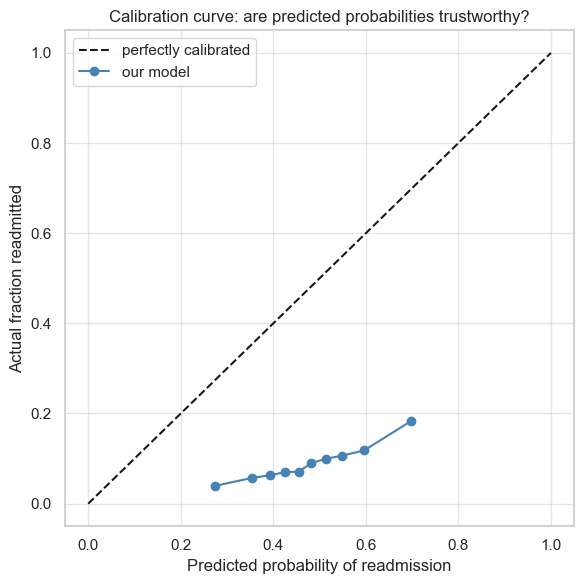

Predicted prob -> Actual fraction that readmitted:
  model said ~27.4%  ->  actually 3.9% readmitted
  model said ~35.4%  ->  actually 5.7% readmitted
  model said ~39.3%  ->  actually 6.3% readmitted
  model said ~42.6%  ->  actually 7.0% readmitted
  model said ~45.5%  ->  actually 7.1% readmitted
  model said ~48.3%  ->  actually 9.0% readmitted
  model said ~51.3%  ->  actually 9.9% readmitted
  model said ~54.8%  ->  actually 10.6% readmitted
  model said ~59.6%  ->  actually 11.8% readmitted
  model said ~69.7%  ->  actually 18.3% readmitted


In [21]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Use the weighted model's probabilities
prob_true, prob_pred = calibration_curve(y_test, y_prob_w, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
ax.plot(prob_pred, prob_true, "o-", color="steelblue", label="our model")
ax.set_xlabel("Predicted probability of readmission")
ax.set_ylabel("Actual fraction readmitted")
ax.set_title("Calibration curve: are predicted probabilities trustworthy?")
ax.legend()
plt.tight_layout()
plt.show()

# Also print the numbers
print("Predicted prob -> Actual fraction that readmitted:")
for pred, true in zip(prob_pred, prob_true):
    print(f"  model said ~{pred:.1%}  ->  actually {true:.1%} readmitted")

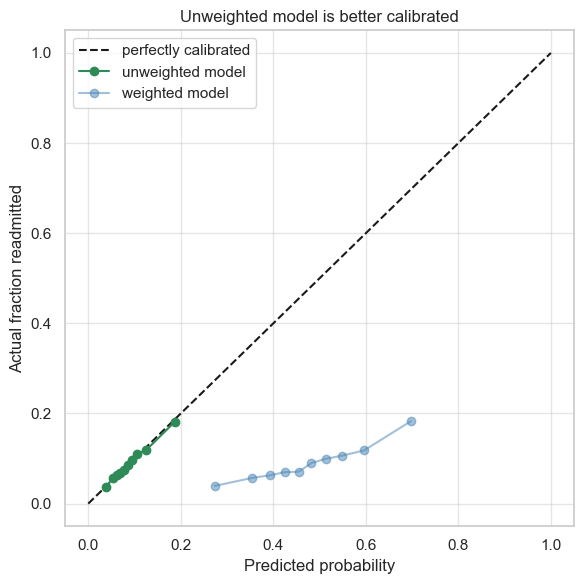

Unweighted model — predicted -> actual:
  ~3.9%  ->  3.8%
  ~5.3%  ->  5.7%
  ~6.1%  ->  6.4%
  ~6.9%  ->  6.8%
  ~7.7%  ->  7.4%
  ~8.5%  ->  8.6%
  ~9.4%  ->  9.8%
  ~10.6%  ->  11.1%
  ~12.5%  ->  11.9%
  ~18.7%  ->  18.1%


In [22]:
from sklearn.calibration import calibration_curve

# The ORIGINAL unweighted model's probabilities (y_prob from earlier)
prob_true_u, prob_pred_u = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
ax.plot(prob_pred_u, prob_true_u, "o-", color="seagreen", label="unweighted model")
ax.plot(prob_pred, prob_true, "o-", color="steelblue", alpha=0.5, label="weighted model")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Actual fraction readmitted")
ax.set_title("Unweighted model is better calibrated")
ax.legend()
plt.tight_layout()
plt.show()

print("Unweighted model — predicted -> actual:")
for pred, true in zip(prob_pred_u, prob_true_u):
    print(f"  ~{pred:.1%}  ->  {true:.1%}")

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Business cost assumption: a missed readmission costs 10x a false alarm.
# (A preventable readmission ~ $10k+; an unnecessary follow-up ~ minutes of staff time.)
COST_FN = 10   # cost of missing an at-risk patient (false negative)
COST_FP = 1    # cost of a false alarm (false positive)

# Use the well-calibrated UNWEIGHTED model's probabilities (y_prob)
thresholds = np.linspace(0.02, 0.9, 100)
costs, recalls, precisions = [], [], []

for t in thresholds:
    pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)
    recalls.append(tp / (tp + fn) if (tp + fn) else 0)
    precisions.append(tp / (tp + fp) if (tp + fp) else 0)

costs = np.array(costs)
best_i = costs.argmin()
best_t = thresholds[best_i]

print(f"Cost assumption: FN = {COST_FN}x, FP = {COST_FP}x")
print(f"\nOptimal threshold: {best_t:.3f}")
print(f"  (vs the naive default of 0.5)")
print(f"At this threshold:")
print(f"  Recall:    {recalls[best_i]:.1%}  (of at-risk patients caught)")
print(f"  Precision: {precisions[best_i]:.1%}  (of flagged patients truly at-risk)")
print(f"  Total cost: {costs[best_i]:,.0f}")

# Compare to the default 0.5 threshold
pred_default = (y_prob >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_default).ravel()
cost_default = fn * COST_FN + fp * COST_FP
print(f"\nFor comparison, threshold 0.5:")
print(f"  Recall {tp/(tp+fn):.1%}, cost {cost_default:,.0f}")
print(f"  -> cost-optimal threshold saves {cost_default - costs[best_i]:,.0f} cost units")

Cost assumption: FN = 10x, FP = 1x

Optimal threshold: 0.091
  (vs the naive default of 0.5)
At this threshold:
  Recall:    54.9%  (of at-risk patients caught)
  Precision: 12.9%  (of flagged patients truly at-risk)
  Total cost: 10,318

For comparison, threshold 0.5:
  Recall 0.4%, cost 12,508
  -> cost-optimal threshold saves 2,190 cost units


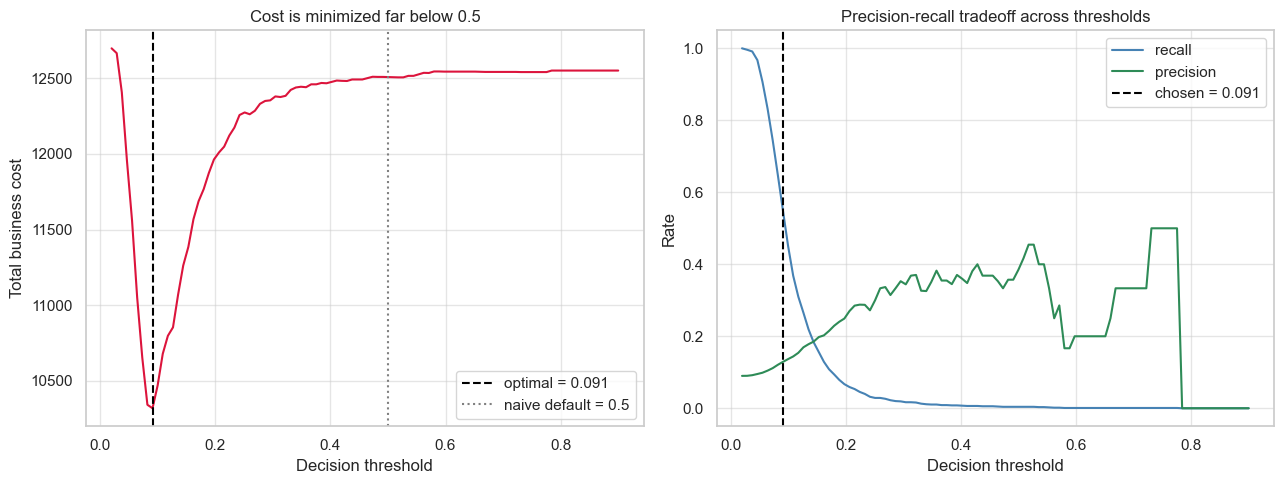

In [24]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Cost vs threshold
ax1.plot(thresholds, costs, color="crimson")
ax1.axvline(best_t, color="black", linestyle="--", label=f"optimal = {best_t:.3f}")
ax1.axvline(0.5, color="gray", linestyle=":", label="naive default = 0.5")
ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Total business cost")
ax1.set_title("Cost is minimized far below 0.5")
ax1.legend()

# Recall & precision vs threshold (the tradeoff)
ax2.plot(thresholds, recalls, label="recall", color="steelblue")
ax2.plot(thresholds, precisions, label="precision", color="seagreen")
ax2.axvline(best_t, color="black", linestyle="--", label=f"chosen = {best_t:.3f}")
ax2.set_xlabel("Decision threshold")
ax2.set_ylabel("Rate")
ax2.set_title("Precision-recall tradeoff across thresholds")
ax2.legend()

plt.tight_layout()
plt.show()

In [25]:
print("How the optimal threshold shifts with the cost ratio:\n")
print(f"{'FN:FP ratio':>12} {'threshold':>10} {'recall':>8} {'precision':>10}")
for ratio in [3, 5, 10, 20, 50]:
    costs_r = []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
        costs_r.append(fn * ratio + fp * 1)
    bi = np.argmin(costs_r)
    pred = (y_prob >= thresholds[bi]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rec = tp/(tp+fn); prec = tp/(tp+fp) if (tp+fp) else 0
    print(f"{ratio:>10}:1 {thresholds[bi]:>10.3f} {rec:>8.1%} {prec:>10.1%}")

How the optimal threshold shifts with the cost ratio:

 FN:FP ratio  threshold   recall  precision
         3:1      0.260     2.9%      33.3%
         5:1      0.180     9.4%      22.9%
        10:1      0.091    54.9%      12.9%
        20:1      0.047    96.7%       9.5%
        50:1      0.020   100.0%       9.0%
